In [1]:
# Importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install openpyxl

In [3]:
# Loading the dataset as a dataframe
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/machine failure project/data_latest.xlsx'
df = pd.read_excel(file_path)

print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Plant  int_Production_Id txt_Production_Number  Prod_Date  Prod_Year  \
0      3              85443      PRD3/46363/14-15 2015-01-02       2015   
1      3              85446      PRD3/46364/14-15 2015-01-01       2015   
2      3              85447      PRD3/46365/14-15 2015-01-01       2015   
3      3              85448      PRD3/46366/14-15 2015-01-01       2015   
4      3              85449      PRD3/46367/14-15 2015-01-01       2015   

   Prod_Month  Prod_Day  Prod_Quarter  Prod_Week  int_Machine_Id  ...  \
0           1         2             1          1              91  ...   
1           1         1             1          1              50  ...   
2           1         1             1          1              16  ...   
3           1         1             1          1             254  ...   
4           1         1             1          1       

After running the above cell to install `openpyxl`, please rerun the cell where you encountered the error to load the dataset.

In [4]:
# Checking the information of all the features in the dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585169 entries, 0 to 585168
Data columns (total 59 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Plant                               585169 non-null  int64         
 1   int_Production_Id                   585169 non-null  int64         
 2   txt_Production_Number               585169 non-null  object        
 3   Prod_Date                           585169 non-null  datetime64[ns]
 4   Prod_Year                           585169 non-null  int64         
 5   Prod_Month                          585169 non-null  int64         
 6   Prod_Day                            585169 non-null  int64         
 7   Prod_Quarter                        585169 non-null  int64         
 8   Prod_Week                           585169 non-null  int64         
 9   int_Machine_Id                      585169 non-null  int64         
 10  Machine 

In [5]:
# Lets create a dictionary to couple the machine ids with the machine names
machine_couples = dict(zip(
    df['int_Machine_Id'],
    df['Machine']
))
machine_couples_2 = dict(zip(
    df['Machine'],
    df['int_Machine_Id']
))
machine_couples_sorted = dict(sorted(machine_couples.items()))
machine_couples_sorted

{1: 'DC 250 H',
 2: 'DC 135 B',
 4: 'TIB-07',
 5: 'DTC-02',
 6: 'DC 350 A',
 7: 'DC 350 B',
 8: 'DC 350 C',
 9: 'DC 135 A',
 10: 'DC 250 G',
 11: 'DC 250 I',
 12: 'DC 420 A',
 13: 'DC 100 A',
 15: 'TCB-01',
 16: 'TCB-02',
 17: 'TCB-06  ',
 18: 'TIB-01',
 19: 'TIB-03',
 20: 'TIB-05',
 21: 'TIB-06',
 22: 'TIB-08',
 23: 'TIB-09',
 24: 'TIB-10   (TCT-04)',
 25: 'TIB-11  (TCT-07)',
 26: 'TIB-12  (TCT-09)',
 27: 'DTC-03',
 28: 'DTC-04',
 29: 'DTC-05',
 30: 'DTC-06',
 31: 'DTC-07',
 32: 'DTC-08',
 33: 'DTC-09',
 34: 'DTC-10',
 35: 'DTC-14',
 36: 'DTC-15',
 37: 'DTC-16',
 38: 'DTC-17',
 39: 'DTC-18',
 40: 'DTC-19  (VMC-006)',
 41: 'DTC-20  (VMC-005)',
 42: 'SPM-01',
 43: 'SPM-02',
 44: 'SPM-03',
 45: 'SPM-05',
 46: 'SPM-06',
 47: 'SPM-07',
 48: 'SM-01',
 49: 'BPM-01',
 50: 'TCM-01',
 51: 'LTM-01',
 52: 'LTM-02',
 53: 'LTM-03  (LTM-004)',
 56: 'CM-02',
 57: 'CM-03',
 58: 'GD3-01',
 59: 'GD3-02',
 60: 'DR-001D',
 61: 'DR-002D',
 62: 'DR-003D',
 63: 'BM350A',
 64: 'BM350B',
 65: 'VM550B',
 67: 'F

In [7]:
#Dropping the irrelevent columns
df.drop(columns = ["int_Operator_Id", "Operator", "int_Supervisor_Id", "Supervisor", "int_Machine_Incharge_Id", "Machine_Incharge", "int_Helper_Id", "Helper", "int_Shift_Id", "Shift"], inplace = True)

In [8]:
# Checking info after dropping few useless features
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585169 entries, 0 to 585168
Data columns (total 49 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Plant                               585169 non-null  int64         
 1   int_Production_Id                   585169 non-null  int64         
 2   txt_Production_Number               585169 non-null  object        
 3   Prod_Date                           585169 non-null  datetime64[ns]
 4   Prod_Year                           585169 non-null  int64         
 5   Prod_Month                          585169 non-null  int64         
 6   Prod_Day                            585169 non-null  int64         
 7   Prod_Quarter                        585169 non-null  int64         
 8   Prod_Week                           585169 non-null  int64         
 9   int_Machine_Id                      585169 non-null  int64         
 10  Machine 

In [9]:
# Checking what machines are given in the dataset (The dataset contains different machines)
machine_ids = df['int_Machine_Id'].unique()

In [10]:
# Sorting the machines by their ids
machine_ids_sorted = sorted(machine_ids)

In [11]:
print(machine_ids_sorted)

[np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(67), np.int64(68), np.int64(69), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78),

In [12]:
machine_ids_list = [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23,
24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42,
43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 56, 57, 58, 59, 60, 61, 62, 63,
64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
85, 86, 87, 91, 92, 157, 158, 189, 190, 191, 192, 193, 194, 195, 196, 197,
198, 199, 200, 201, 202, 205, 206, 207, 208, 209, 210, 214, 254, 256, 257,
259, 260, 261, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280,
281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295,
296, 297, 298, 299, 300, 301, 307, 308, 309, 311, 312, 313, 320, 321, 347,
357, 361, 367, 368, 369, 381, 383]

#Creating a dictionary to store dataframe's machine wise
machine_dfs = {}

# Creating dataframe's machine wise
for machine_id in machine_ids_list:
    machine_dfs[f"machine_{machine_id}"] = df[df['int_Machine_Id'] == machine_id].copy()

In [13]:
#Segregated the data machine wise
#Now we will perform exploratory data analysis on each machine

##Machine ID:1
machine_dfs['machine_1'].head()

,Plant,int_Production_Id,txt_Production_Number,Prod_Date,Prod_Year,Prod_Month,Prod_Day,Prod_Quarter,Prod_Week,int_Machine_Id,...,COBD_Equ_Hours,COBD_Prd_Hours,COBD_Equ,COBD_Prd,COBD_Total,int_Seq_no,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58
68531,3,139002,PRD3/40008/15-16,2015-12-19,2015,12,19,4,51,1,...,0,0,0.0,0,0.0,68532.0,NaN,NaN,NaN,NaN
68532,3,139003,PRD3/39952/15-16,2015-12-19,2015,12,19,4,51,1,...,0,0,0.0,0,0.0,68533.0,NaN,NaN,NaN,NaN
68536,3,139009,PRD3/39940/15-16,2015-12-19,2015,12,19,4,51,1,...,0,0,0.0,0,0.0,68537.0,NaN,NaN,NaN,NaN
68537,3,139010,PRD3/40004/15-16,2015-12-19,2015,12,19,4,51,1,...,0,0,0.0,0,0.0,68538.0,NaN,NaN,NaN,NaN
68542,3,139017,PRD3/39925/15-16,2015-12-20,2015,12,20,4,52,1,...,0,0,0.0,0,0.0,68543.0,NaN,NaN,NaN,NaN


In [14]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6747 entries, 68531 to 518779
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Plant                               6747 non-null   int64         
 1   int_Production_Id                   6747 non-null   int64         
 2   txt_Production_Number               6747 non-null   object        
 3   Prod_Date                           6747 non-null   datetime64[ns]
 4   Prod_Year                           6747 non-null   int64         
 5   Prod_Month                          6747 non-null   int64         
 6   Prod_Day                            6747 non-null   int64         
 7   Prod_Quarter                        6747 non-null   int64         
 8   Prod_Week                           6747 non-null   int64         
 9   int_Machine_Id                      6747 non-null   int64         
 10  Machine                

In [15]:
# Checking for missing values
machine_dfs['machine_1'].isna().sum()

,0
Plant,0
int_Production_Id,0
txt_Production_Number,0
Prod_Date,0
Prod_Year,0
Prod_Month,0
Prod_Day,0
Prod_Quarter,0
Prod_Week,0
int_Machine_Id,0


In [16]:
#Lot of missing values in txt_Customer_Name, txt_Updated_By, dte_Updated_Date, Unnamed: 55, Unnamed: 56, Unnamed: 57, Unnamed: 58
#All the above columns can be removed as txt_Customer_Name, txt_Updated_By, dte_Updated_Date, txt_Created_By are irrelevent and all values from Unnamed: 55, Unnamed: 56, Unnamed: 57, Unnamed: 58 are missing
# 'Plant', 'int_Machine_Id', 'Machine', 'int_Operation_Id', 'Operation', 'Department', 'Source', 'int_Company_Id', 'int_Principle_Id', 'txt_Principle_Code' are features with unique values for a machine
# "txt_Customer_Product_Code"

In [17]:
# Checking for the features with unique values
for column in machine_dfs['machine_1'].columns:
    if machine_dfs['machine_1'][column].unique().size == 1:
        print(column)

Plant
int_Machine_Id
Machine
int_Operation_Id
Operation
Department
Source
int_Company_Id
int_Principle_Id
txt_Principle_Code
Unnamed: 55
Unnamed: 56
Unnamed: 57
Unnamed: 58


In [19]:
# Dropping irrelevent columns again
machine_dfs['machine_1'].drop(
    columns=['txt_Customer_Name', 'txt_Updated_By', 'dte_Updated_Date',
             'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58',
             'Plant', 'int_Machine_Id', 'int_Operation_Id',
             'Operation', 'Department', 'Source', 'int_Company_Id',
             'int_Principle_Id', 'txt_Principle_Code', 'txt_Created_By' ],
    inplace=True,
    errors='ignore'
)

In [20]:
# Checking the features again
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6747 entries, 68531 to 518779
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   6747 non-null   int64         
 1   txt_Production_Number               6747 non-null   object        
 2   Prod_Date                           6747 non-null   datetime64[ns]
 3   Prod_Year                           6747 non-null   int64         
 4   Prod_Month                          6747 non-null   int64         
 5   Prod_Day                            6747 non-null   int64         
 6   Prod_Quarter                        6747 non-null   int64         
 7   Prod_Week                           6747 non-null   int64         
 8   Machine                             6747 non-null   object        
 9   int_Product_Id                      6747 non-null   int64         
 10  txt_Product_Code       

In [21]:
# Creating a single date column to remove all other time related columns
machine_dfs['machine_1']['date'] = machine_dfs['machine_1']['Prod_Day'].astype(str) + '-' + machine_dfs['machine_1']['Prod_Month'].astype(str) + '-' + machine_dfs['machine_1']['Prod_Year'].astype(str)
machine_dfs['machine_1']['date']

,date
68531,19-12-2015
68532,19-12-2015
68536,19-12-2015
68537,19-12-2015
68542,20-12-2015
...,...
518463,17-7-2019
518467,29-6-2019
518630,24-7-2019
518727,24-7-2019


In [22]:
# Changing the datatype to a datetime delta
machine_dfs['machine_1']['date'] = pd.to_datetime(machine_dfs['machine_1']['date'], format='%d-%m-%Y')

In [23]:
# Checking the features again
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6747 entries, 68531 to 518779
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   6747 non-null   int64         
 1   txt_Production_Number               6747 non-null   object        
 2   Prod_Date                           6747 non-null   datetime64[ns]
 3   Prod_Year                           6747 non-null   int64         
 4   Prod_Month                          6747 non-null   int64         
 5   Prod_Day                            6747 non-null   int64         
 6   Prod_Quarter                        6747 non-null   int64         
 7   Prod_Week                           6747 non-null   int64         
 8   Machine                             6747 non-null   object        
 9   int_Product_Id                      6747 non-null   int64         
 10  txt_Product_Code       

In [24]:
# Asked to work only on electrical and mechanical failures
# Neglect COBD - Cost of breakdown for now
# Remove all time/date indicating columns as they have been merged into date

In [25]:
machine_dfs['machine_1'].drop(columns = ['Prod_Year', 'Prod_Month', 'Prod_Day', 'Prod_Quarter',
                                         'Prod_Week','txt_Production_Number', 'txt_Customer_Product_Code', 'txt_Customer_Product_Name',
                                         'DL_Flag', 'Idle_Flag', 'Machine'], inplace = True, errors='ignore')

In [26]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6747 entries, 68531 to 518779
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   6747 non-null   int64         
 1   Prod_Date                           6747 non-null   datetime64[ns]
 2   int_Product_Id                      6747 non-null   int64         
 3   txt_Product_Code                    6747 non-null   object        
 4   txt_Product_Name                    6747 non-null   object        
 5   int_Production_Product_Id           6747 non-null   object        
 6   Production_Hours                    6747 non-null   object        
 7   Breakdown_Hours                     6747 non-null   object        
 8   int_Production_Breakdown_Detail_Id  6747 non-null   float64       
 9   int_Breakdown_Type_Id               6747 non-null   float64       
 10  Breakdown_Code         

In [27]:
# Lets create a dictionary to couple the breakdown codes with the breakdown types
breakdown_couples = dict(zip(
    machine_dfs['machine_1']['Breakdown_Code'],
    machine_dfs['machine_1']['Breakdown_Type']
))

In [28]:
breakdown_couples

{' ': 'NO BREAKDOWN',
 'K': 'Plunger Change',
 'A': 'Die Breakdown',
 'B': 'Die Loading & Unloading',
 'F': 'Mechanical Break down',
 'H': 'Metal Charging',
 'N': 'Slag Removel',
 'M': 'Pre Heat',
 'G': 'Metal Bailout',
 'J': 'Operator shortage',
 'O': 'Cleaning',
 'C': 'Die Maintenance',
 'V': 'Dycote Filling',
 'U': 'No Plan',
 'E': 'Furnace Breakdown',
 'L': 'Power Cut',
 'D': 'Electrical Breakdown',
 'S': 'Casting Shortage',
 'Q': 'Tool/Insert Change',
 'Z': 'Unloading Die / Fixture',
 'I': 'N2 Charging'}

In [29]:
# Now we have to consider only electrical and mechanical breakdowns
# Those are 'D' and 'F'

In [30]:
# Removing all other breakdown types other than electrical and mechanical breakdowns
machine_dfs['machine_1'] = machine_dfs['machine_1'][
    machine_dfs['machine_1']['Breakdown_Code'].isin([' ','D', 'F'])
].copy()

In [31]:
machine_dfs['machine_1'].head()

,int_Production_Id,Prod_Date,int_Product_Id,txt_Product_Code,txt_Product_Name,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,...,dte_Created_Date,Eq_Excl_Flag,MSR_Flag,COBD_Equ_Hours,COBD_Prd_Hours,COBD_Equ,COBD_Prd,COBD_Total,int_Seq_no,date
68531,139002,2015-12-19,554,PL01A3011/D,DE BRACKET 26219174/D,299832,2,0,0.0,0.0,...,2015-12-21 15:18:05.993000,,,0,0,0.0,0,0.0,68532.0,2015-12-19
68532,139003,2015-12-19,502,PL04A3016/D,GEAR BOX 26718205/D,299833,6,0,0.0,0.0,...,2015-12-21 15:19:58.620000,,,0,0,0.0,0,0.0,68533.0,2015-12-19
68536,139009,2015-12-19,550,PL01A3019/D,DE BRACKET 26211301/D,299839,5,0,0.0,0.0,...,2015-12-21 15:30:21.943000,,,0,0,0.0,0,0.0,68537.0,2015-12-19
68537,139010,2015-12-19,554,PL01A3011/D,DE BRACKET 26219174/D,299840,3,0,0.0,0.0,...,2015-12-21 15:32:15.947000,,,0,0,0.0,0,0.0,68538.0,2015-12-19
68542,139017,2015-12-20,550,PL01A3019/D,DE BRACKET 26211301/D,299846,8,0,0.0,0.0,...,2015-12-21 15:48:26.857000,,,0,0,0.0,0,0.0,68543.0,2015-12-20


In [32]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1614 entries, 68531 to 518779
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   1614 non-null   int64         
 1   Prod_Date                           1614 non-null   datetime64[ns]
 2   int_Product_Id                      1614 non-null   int64         
 3   txt_Product_Code                    1614 non-null   object        
 4   txt_Product_Name                    1614 non-null   object        
 5   int_Production_Product_Id           1614 non-null   object        
 6   Production_Hours                    1614 non-null   object        
 7   Breakdown_Hours                     1614 non-null   object        
 8   int_Production_Breakdown_Detail_Id  1614 non-null   float64       
 9   int_Breakdown_Type_Id               1614 non-null   float64       
 10  Breakdown_Code         

In [33]:
machine_dfs['machine_1']['Breakdown_Code'].unique()

array([' ', 'F', 'D'], dtype=object)

In [34]:
# Converting all non-numeric features to numeric using one-hot encoding
non_numeric_columns = [
    "txt_Product_Code",
    "txt_Product_Name",
    "int_Production_Product_Id",
    "Production_Hours",
    "Breakdown_Hours",
    "Breakdown_Code",
    "Breakdown_Type",
    "dte_Created_Date",
    "Eq_Excl_Flag",
    "MSR_Flag",
    "COBD_Prd_Hours",
    "COBD_Prd",
    "COBD_Equ_Hours"
]
for col in non_numeric_columns:
    machine_dfs['machine_1'][col] = pd.to_numeric(machine_dfs['machine_1'][col], errors='coerce').fillna(0).astype(int)

In [35]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1614 entries, 68531 to 518779
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   1614 non-null   int64         
 1   Prod_Date                           1614 non-null   datetime64[ns]
 2   int_Product_Id                      1614 non-null   int64         
 3   txt_Product_Code                    1614 non-null   int64         
 4   txt_Product_Name                    1614 non-null   int64         
 5   int_Production_Product_Id           1614 non-null   int64         
 6   Production_Hours                    1614 non-null   int64         
 7   Breakdown_Hours                     1614 non-null   int64         
 8   int_Production_Breakdown_Detail_Id  1614 non-null   float64       
 9   int_Breakdown_Type_Id               1614 non-null   float64       
 10  Breakdown_Code         

In [36]:
# Standardizing all the features
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

for col in machine_dfs['machine_1'].columns:
    if col != 'date':
      machine_dfs['machine_1'][col] = sc.fit_transform(machine_dfs['machine_1'][col].values.reshape(-1, 1))

In [37]:
machine_dfs['machine_1'].head()

,int_Production_Id,Prod_Date,int_Product_Id,txt_Product_Code,txt_Product_Name,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,...,dte_Created_Date,Eq_Excl_Flag,MSR_Flag,COBD_Equ_Hours,COBD_Prd_Hours,COBD_Equ,COBD_Prd,COBD_Total,int_Seq_no,date
68531,-1.892265,-0.701136,-0.451610,0.0,0.0,-1.260766,-1.406339,-0.499578,-0.92502,-0.387663,...,0.0,0.0,0.0,-0.499578,0.0,-0.545692,0.0,-0.545692,-1.194982,2015-12-19
68532,-1.892245,-0.701136,-0.458063,0.0,0.0,-1.260759,0.081587,-0.499578,-0.92502,-0.387663,...,0.0,0.0,0.0,-0.499578,0.0,-0.545692,0.0,-0.545692,-1.194975,2015-12-19
68536,-1.892130,-0.701136,-0.452106,0.0,0.0,-1.260721,-0.290394,-0.499578,-0.92502,-0.387663,...,0.0,0.0,0.0,-0.499578,0.0,-0.545692,0.0,-0.545692,-1.194948,2015-12-19
68537,-1.892110,-0.701136,-0.451610,0.0,0.0,-1.260715,-1.034358,-0.499578,-0.92502,-0.387663,...,0.0,0.0,0.0,-0.499578,0.0,-0.545692,0.0,-0.545692,-1.194941,2015-12-19
68542,-1.891975,-0.699016,-0.452106,0.0,0.0,-1.260677,0.825550,-0.499578,-0.92502,-0.387663,...,0.0,0.0,0.0,-0.499578,0.0,-0.545692,0.0,-0.545692,-1.194908,2015-12-20


In [38]:
# Breakdown_Code	Breakdown_Type	dte_Created_Date	Eq_Excl_Flag	MSR_Flag
# Removing these features as they show no correleation
machine_dfs['machine_1'].drop(columns = ['Breakdown_Code', 'Breakdown_Type', 'dte_Created_Date', 'Eq_Excl_Flag', 'MSR_Flag','txt_Product_Code','txt_Product_Name','COBD_Prd_Hours','COBD_Prd'], inplace = True, errors='ignore')

In [39]:
machine_dfs['machine_1'].corr()

,int_Production_Id,Prod_Date,int_Product_Id,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,COBD_Equ_Hours,COBD_Equ,COBD_Total,int_Seq_no,date
int_Production_Id,1.000000,0.981486,-0.050528,0.991974,0.414556,-0.007842,0.034995,0.034439,-0.007842,-0.061145,-0.061145,0.506439,0.981486
Prod_Date,0.981486,1.000000,-0.075264,0.983069,0.449243,-0.009271,0.029117,0.032263,-0.009271,-0.063377,-0.063377,0.507830,1.000000
int_Product_Id,-0.050528,-0.075264,1.000000,-0.045590,-0.140224,0.010880,-0.016380,0.067091,0.010880,0.059140,0.059140,-0.020812,-0.075264
int_Production_Product_Id,0.991974,0.983069,-0.045590,1.000000,0.417725,-0.025343,0.006967,0.019702,-0.025343,-0.080062,-0.080062,0.508463,0.983069
Production_Hours,0.414556,0.449243,-0.140224,0.417725,1.000000,0.141304,-0.260225,-0.072132,0.141304,0.097657,0.097657,0.172128,0.449243
Breakdown_Hours,-0.007842,-0.009271,0.010880,-0.025343,0.141304,1.000000,0.523715,0.457378,1.000000,0.932857,0.932857,-0.030718,-0.009271
int_Production_Breakdown_Detail_Id,0.034995,0.029117,-0.016380,0.006967,-0.260225,0.523715,1.000000,0.432181,0.523715,0.537692,0.537692,0.014200,0.029117
int_Breakdown_Type_Id,0.034439,0.032263,0.067091,0.019702,-0.072132,0.457378,0.432181,1.000000,0.457378,0.426161,0.426161,-0.010983,0.032263
COBD_Equ_Hours,-0.007842,-0.009271,0.010880,-0.025343,0.141304,1.000000,0.523715,0.457378,1.000000,0.932857,0.932857,-0.030718,-0.009271
COBD_Equ,-0.061145,-0.063377,0.059140,-0.080062,0.097657,0.932857,0.537692,0.426161,0.932857,1.000000,1.000000,-0.039782,-0.063377


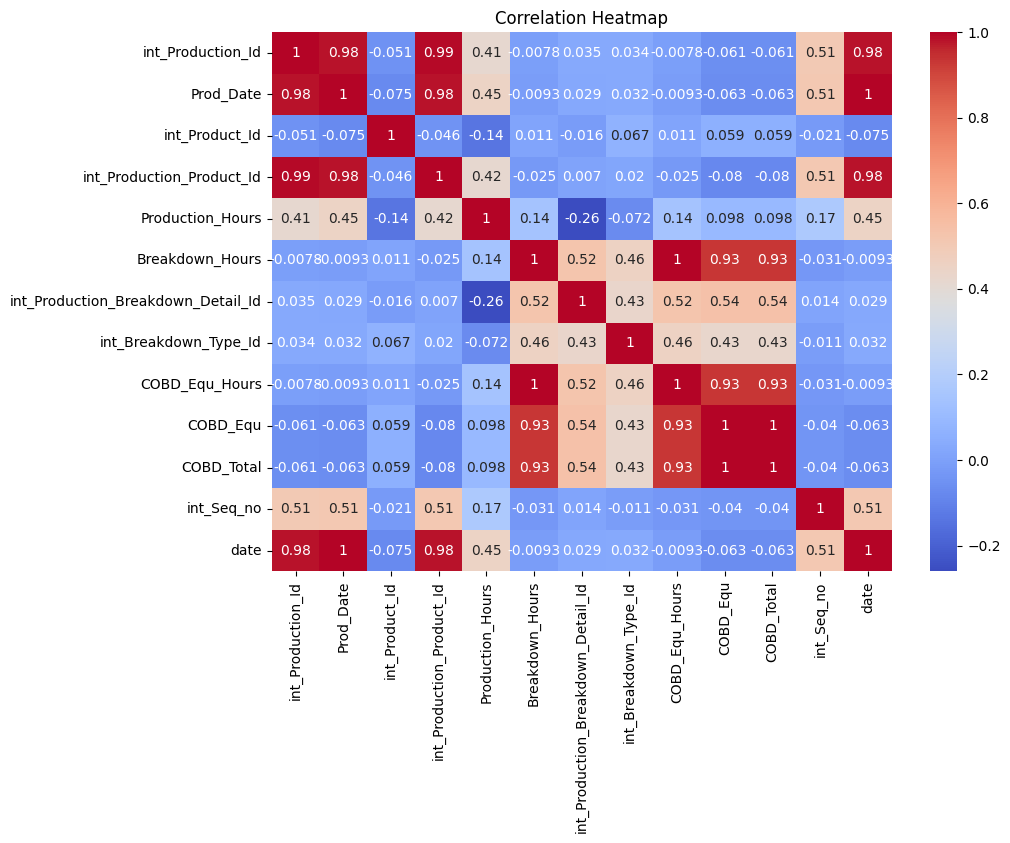

In [40]:
# Lets plot a heatmap for a better understanding on the correlations
plt.figure(figsize = (10, 7))
sns.heatmap(machine_dfs['machine_1'].corr(), cmap = "coolwarm", annot = True)
plt.title("Correlation Heatmap")
plt.show()

In [41]:
# Creating a new column to show yes/no breakdown
machine_dfs['machine_1']['Breakdown_Flag'] = machine_dfs['machine_1']['Breakdown_Hours'].apply(lambda x: 1 if x > 0 else 0)

In [42]:
machine_dfs['machine_1'].head()

,int_Production_Id,Prod_Date,int_Product_Id,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,COBD_Equ_Hours,COBD_Equ,COBD_Total,int_Seq_no,date,Breakdown_Flag
68531,-1.892265,-0.701136,-0.451610,-1.260766,-1.406339,-0.499578,-0.92502,-0.387663,-0.499578,-0.545692,-0.545692,-1.194982,2015-12-19,0
68532,-1.892245,-0.701136,-0.458063,-1.260759,0.081587,-0.499578,-0.92502,-0.387663,-0.499578,-0.545692,-0.545692,-1.194975,2015-12-19,0
68536,-1.892130,-0.701136,-0.452106,-1.260721,-0.290394,-0.499578,-0.92502,-0.387663,-0.499578,-0.545692,-0.545692,-1.194948,2015-12-19,0
68537,-1.892110,-0.701136,-0.451610,-1.260715,-1.034358,-0.499578,-0.92502,-0.387663,-0.499578,-0.545692,-0.545692,-1.194941,2015-12-19,0
68542,-1.891975,-0.699016,-0.452106,-1.260677,0.825550,-0.499578,-0.92502,-0.387663,-0.499578,-0.545692,-0.545692,-1.194908,2015-12-20,0


In [43]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1614 entries, 68531 to 518779
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   1614 non-null   float64       
 1   Prod_Date                           1614 non-null   float64       
 2   int_Product_Id                      1614 non-null   float64       
 3   int_Production_Product_Id           1614 non-null   float64       
 4   Production_Hours                    1614 non-null   float64       
 5   Breakdown_Hours                     1614 non-null   float64       
 6   int_Production_Breakdown_Detail_Id  1614 non-null   float64       
 7   int_Breakdown_Type_Id               1614 non-null   float64       
 8   COBD_Equ_Hours                      1614 non-null   float64       
 9   COBD_Equ                            1614 non-null   float64       
 10  COBD_Total             

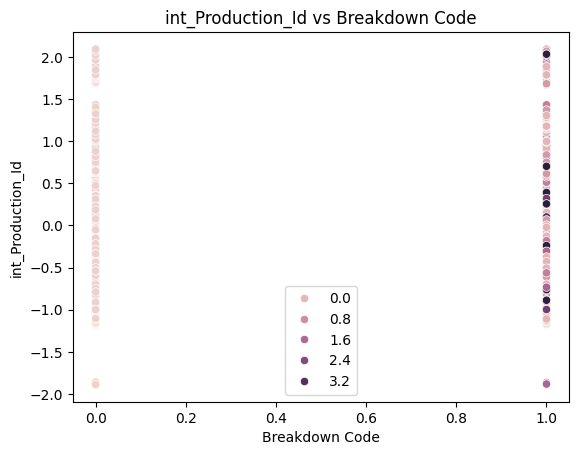

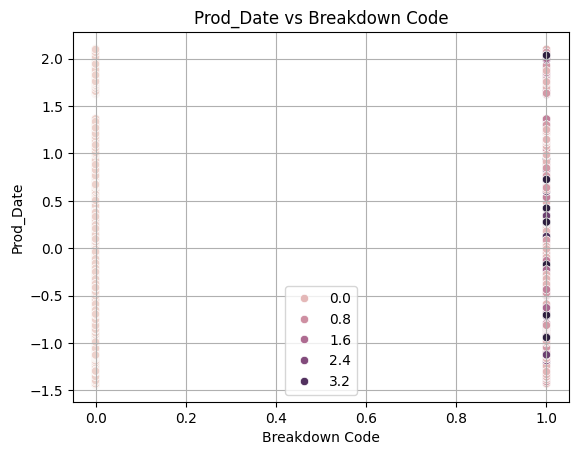

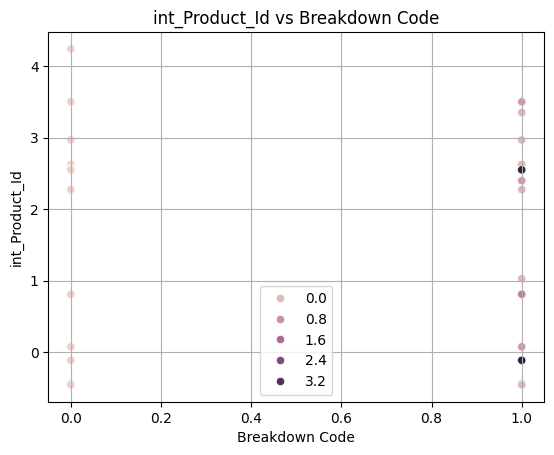

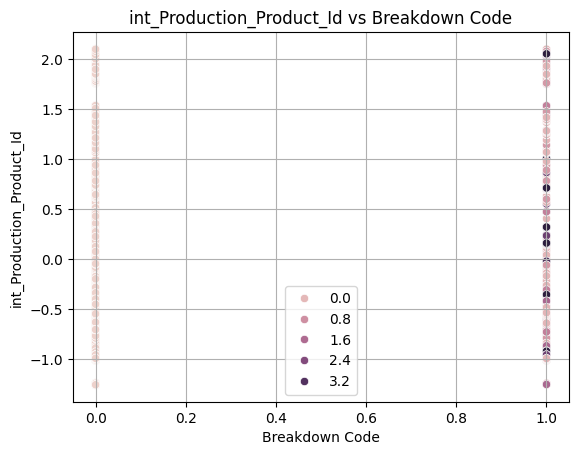

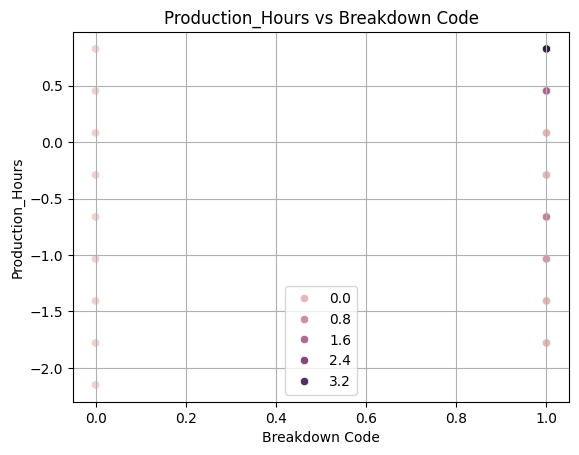

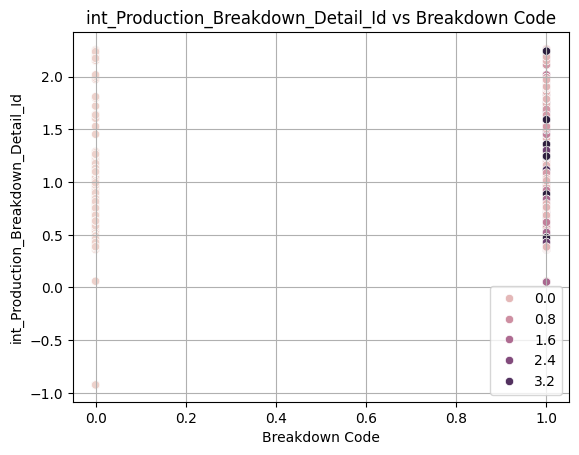

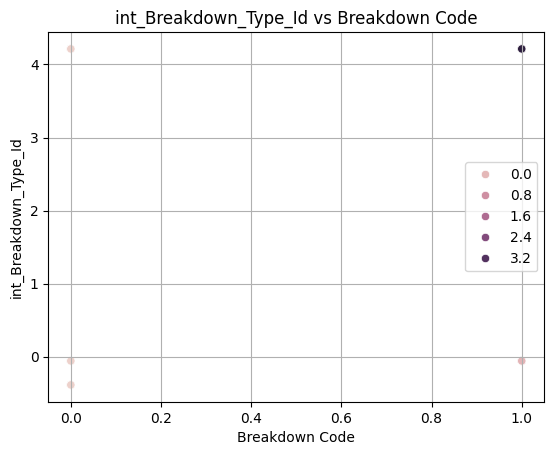

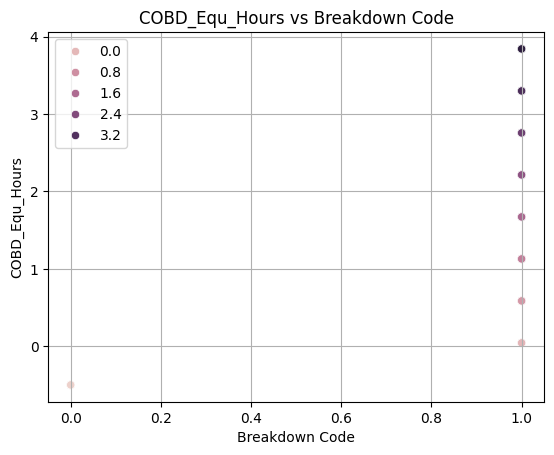

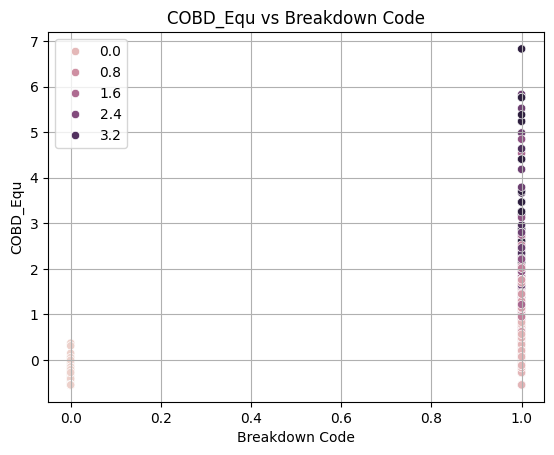

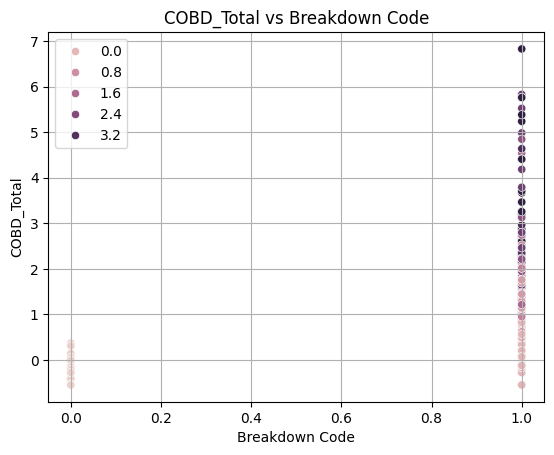

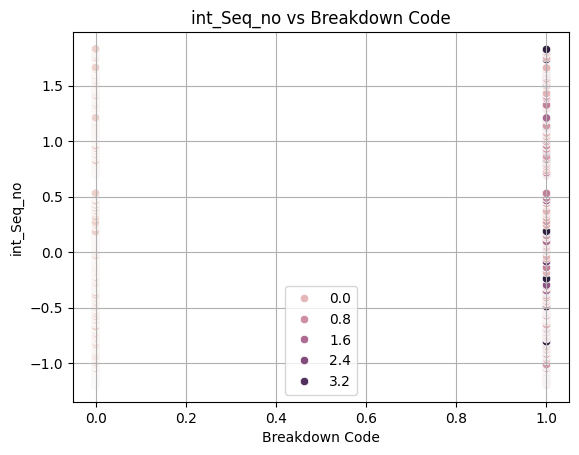

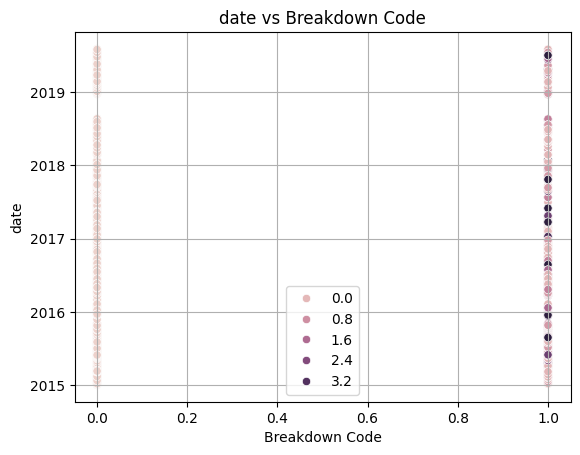

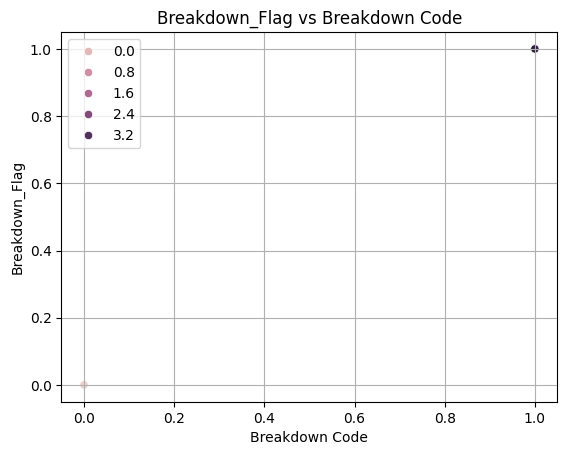

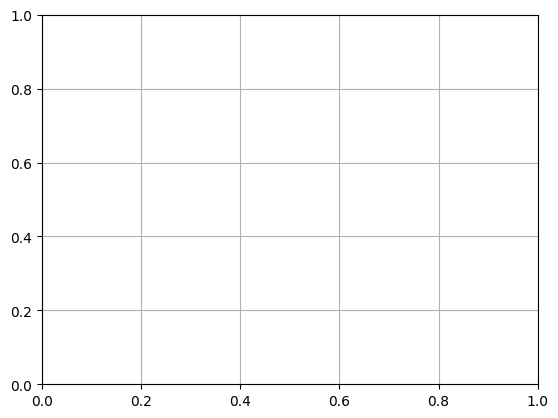

In [44]:
# Plotting scatter plots of all the features against breakdown hours to find any meaning patterns
for col in machine_dfs['machine_1'].columns:
  if col != 'Breakdown_Hours':
    sns.scatterplot(x = machine_dfs['machine_1']['Breakdown_Flag'],
                y = machine_dfs['machine_1'][col],
                hue = machine_dfs['machine_1']['Breakdown_Hours'],)
    plt.title(f'{col} vs Breakdown Code')
    plt.legend()
    plt.xlabel('Breakdown Code')
    plt.ylabel(col)
    plt.show()
    plt.grid()


In [45]:
machine_dfs['machine_1']

,int_Production_Id,Prod_Date,int_Product_Id,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,COBD_Equ_Hours,COBD_Equ,COBD_Total,int_Seq_no,date,Breakdown_Flag
68531,-1.892265,-0.701136,-0.451610,-1.260766,-1.406339,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.194982,2015-12-19,0
68532,-1.892245,-0.701136,-0.458063,-1.260759,0.081587,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.194975,2015-12-19,0
68536,-1.892130,-0.701136,-0.452106,-1.260721,-0.290394,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.194948,2015-12-19,0
68537,-1.892110,-0.701136,-0.451610,-1.260715,-1.034358,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.194941,2015-12-19,0
68542,-1.891975,-0.699016,-0.452106,-1.260677,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.194908,2015-12-20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517817,1.886148,1.872671,-0.458063,1.932979,0.081587,0.043032,2.190353,-0.059045,0.043032,0.565807,0.565807,1.824280,2019-04-16,1
517928,2.022617,2.021078,-0.456946,2.047465,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,1.825026,2019-06-25,0
518054,2.032993,2.035919,-0.115661,2.054757,0.825550,3.841306,2.243604,4.212984,3.841306,3.256174,3.256174,1.825872,2019-07-02,1
518463,2.068710,2.067721,-0.458063,2.080020,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,1.828621,2019-07-17,0


In [46]:
machine_dfs['machine_1'] = machine_dfs['machine_1'].sort_values(by = 'date')
machine_dfs['machine_1']

,int_Production_Id,Prod_Date,int_Product_Id,int_Production_Product_Id,Production_Hours,Breakdown_Hours,int_Production_Breakdown_Detail_Id,int_Breakdown_Type_Id,COBD_Equ_Hours,COBD_Equ,COBD_Total,int_Seq_no,date,Breakdown_Flag
70810,-1.178737,-1.443172,-0.450865,-1.018771,-0.662376,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.179666,2015-01-03,0
70798,-1.178892,-1.443172,-0.450865,-1.018822,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.179747,2015-01-03,0
70985,-1.175613,-1.436812,2.260426,-1.017743,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.178490,2015-01-06,0
71085,-1.173665,-1.434692,2.273084,-1.017102,-0.662376,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.177818,2015-01-07,0
71142,-1.172547,-1.432572,2.273084,-1.016734,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,-1.177435,2015-01-08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387751,2.091044,2.097402,-0.456326,2.098708,-1.034358,0.585643,2.263617,-0.059045,0.585643,0.381007,0.381007,0.950219,2019-07-31,1
518779,2.093281,2.097402,-0.456946,2.100308,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,1.830744,2019-07-31,0
388063,2.094245,2.099522,-0.456946,2.101209,0.825550,-0.499578,-0.925020,-0.387663,-0.499578,-0.545692,-0.545692,0.952316,2019-08-01,0
388034,2.094149,2.099522,-0.456946,2.101050,-1.034358,0.043032,2.264457,-0.059045,0.043032,-0.002494,-0.002494,0.952121,2019-08-01,1


In [47]:
machine_dfs['machine_1'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1614 entries, 70810 to 388129
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   int_Production_Id                   1614 non-null   float64       
 1   Prod_Date                           1614 non-null   float64       
 2   int_Product_Id                      1614 non-null   float64       
 3   int_Production_Product_Id           1614 non-null   float64       
 4   Production_Hours                    1614 non-null   float64       
 5   Breakdown_Hours                     1614 non-null   float64       
 6   int_Production_Breakdown_Detail_Id  1614 non-null   float64       
 7   int_Breakdown_Type_Id               1614 non-null   float64       
 8   COBD_Equ_Hours                      1614 non-null   float64       
 9   COBD_Equ                            1614 non-null   float64       
 10  COBD_Total             

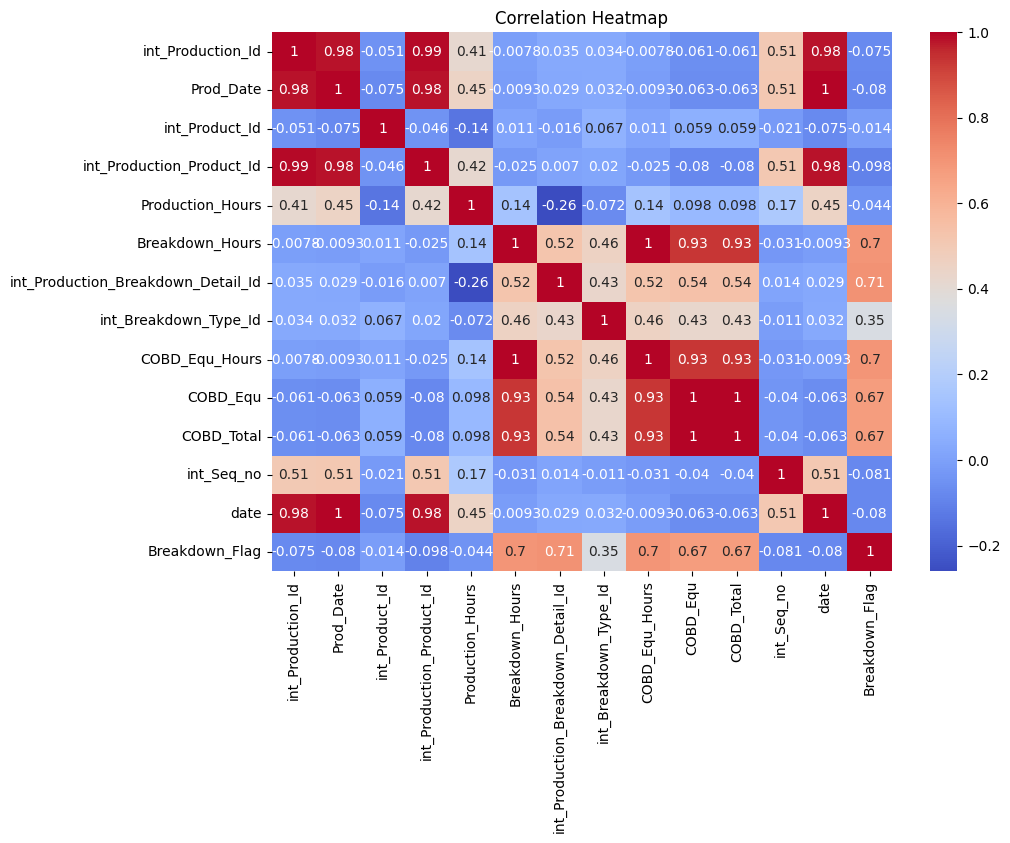

In [48]:
# Lets plot a heatmap for a better understanding on the correlations
plt.figure(figsize = (10, 7))
sns.heatmap(machine_dfs['machine_1'].corr(), cmap = "coolwarm", annot = True)
plt.title("Correlation Heatmap")
plt.show()

In [49]:
# The value to be predicted is Breakdown_Flag
# The features used to biuld the model are int_Product_Id, int_Production_Product_Id, Production_Hours, int_Production_Breakdown_Detail_Id, int_Breakdown_Type_Id, Days_Since_Last_Breakdown

In [50]:
from sklearn.model_selection import train_test_split
X = machine_dfs['machine_1'][['int_Product_Id', 'Production_Hours',
                                    'int_Production_Breakdown_Detail_Id',
                                    'int_Breakdown_Type_Id']]
y = machine_dfs['machine_1']['Breakdown_Flag']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [52]:
y_pred = model.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
con_mat = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("FOR THE LOGISTIC REGRESSION CLASSIFIER")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{con_mat}")

FOR THE LOGISTIC REGRESSION CLASSIFIER
Accuracy: 0.8606811145510835
Precision: 0.7865168539325843
Recall: 0.7291666666666666
F1 Score: 0.7567567567567568
Confusion Matrix:
[[208  19]
 [ 26  70]]


In [54]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators = 100, random_state = 42)
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [55]:
y_pred_random_forest = random_forest.predict(X_test)

In [56]:
accuracy = accuracy_score(y_test, y_pred_random_forest)
precision = precision_score(y_test, y_pred_random_forest)
recall = recall_score(y_test, y_pred_random_forest)
con_mat = confusion_matrix(y_test, y_pred_random_forest)
f1 = f1_score(y_test, y_pred_random_forest)

print("FOR THE RANDOM FOREST CLASSIFIER")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{con_mat}")

FOR THE RANDOM FOREST CLASSIFIER
Accuracy: 0.8606811145510835
Precision: 0.7339449541284404
Recall: 0.8333333333333334
F1 Score: 0.7804878048780488
Confusion Matrix:
[[198  29]
 [ 16  80]]


In [59]:
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier

xgb_classifier = XGBClassifier(n_estimators = 100, random_state = 42)
xgb_classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [58]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.9/295.9 MB 1.3 MB/s eta 0:00:00


In [60]:
y_pred_xgb = xgb_classifier.predict(X_test)

In [61]:
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
con_mat = confusion_matrix(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("FOR THE XGBoost CLASSIFIER")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{con_mat}")

FOR THE XGBoost CLASSIFIER
Accuracy: 0.8947368421052632
Precision: 0.7818181818181819
Recall: 0.8958333333333334
F1 Score: 0.8349514563106796
Confusion Matrix:
[[203  24]
 [ 10  86]]


In [62]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state = 42)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
y_pred_decision_tree = decision_tree.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
con_mat = confusion_matrix(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

print("FOR THE Decision tree CLASSIFIER")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{con_mat}")

FOR THE Decision tree CLASSIFIER
Accuracy: 0.8947368421052632
Precision: 0.7818181818181819
Recall: 0.8958333333333334
F1 Score: 0.8349514563106796
Confusion Matrix:
[[203  24]
 [ 10  86]]


In [65]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

In [66]:
y_pred_svm = svm_model.predict(X_test)

In [67]:
accuracy = accuracy_score(y_test, y_pred_svm)
precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)
con_mat = confusion_matrix(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm)

print("FOR THE SVM CLASSIFIER")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix:\n{con_mat}")

FOR THE SVM CLASSIFIER
Accuracy: 0.8885448916408669
Precision: 0.7678571428571429
Recall: 0.8958333333333334
F1 Score: 0.8269230769230769
Confusion Matrix:
[[201  26]
 [ 10  86]]
